# PCOS Model Comparison — Formal Statistical Testing
**Dataset:** 541 Indian women (177 PCOS, 364 controls)

This notebook re-runs all five models (Logistic Regression, Ridge, LASSO, XGBoost, Random Forest)
using **identical fixed CV splits** to produce paired fold-level AUC scores, then applies
Wilcoxon signed-rank tests to determine whether performance differences are statistically significant.

Addresses report Section 4.4 limitation: *'The formal statistical comparison of model performance
has not been completed.'*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import wilcoxon
from xgboost import XGBClassifier
from itertools import combinations

print('Imports successful')

Imports successful


## 1. Load Data & Define Feature Sets

In [2]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
df = df.drop(columns=['sl_no', 'patient_file_no'], errors='ignore')
df['ii_beta_hcg_miu_ml'] = pd.to_numeric(df['ii_beta_hcg_miu_ml'], errors='coerce')
df = df.fillna(df.median(numeric_only=True))

full_features = [c for c in df.columns if c != 'pcos_y_n']

low_cost_features = [
    'age_yrs', 'bmi', 'weight_kg', 'waist_hip_ratio',
    'pulse_ratebpm', 'rr_breaths_min', 'cycle_r_i', 'cycle_lengthdays',
    'bp_systolic_mmhg', 'bp_diastolic_mmhg',
    'weight_gain_y_n', 'hair_growth_y_n', 'skin_darkening_y_n',
    'hair_loss_y_n', 'pimples_y_n', 'fast_food_y_n',
    'reg_exercise_y_n', 'pregnant_y_n'
]

X_full = df[full_features]
X_low  = df[low_cost_features]
y      = df['pcos_y_n']

print(f'Full: {X_full.shape[1]} features  |  Low-cost: {X_low.shape[1]} features')

Full: 41 features  |  Low-cost: 18 features


## 2. Define Models

All models use the same `outer_cv` splits for a fair paired comparison.
StandardScaler is applied inside each pipeline.

In [3]:
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scale-inside-pipeline for each model
def make_pipeline(estimator):
    return Pipeline([('scaler', StandardScaler()), ('model', estimator)])

models = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(penalty='l2', C=1.0, max_iter=1000, random_state=42)
    ),
    'Ridge': make_pipeline(
        LogisticRegression(penalty='l2', C=0.1, max_iter=1000, random_state=42)
    ),
    'LASSO': make_pipeline(
        LogisticRegression(penalty='l1', C=0.1, solver='liblinear', max_iter=1000, random_state=42)
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=(364/177),  # neg/pos ratio
            eval_metric='logloss', random_state=42, n_jobs=-1
        )
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(
            n_estimators=300, max_depth=10, min_samples_split=5,
            class_weight='balanced', random_state=42, n_jobs=-1
        )
    ),
}

print(f'{len(models)} models defined')

5 models defined


## 3. Collect Fold-Level AUC Scores

Using the **same CV splits** for all models so fold scores are paired.

In [4]:
def get_fold_aucs(models_dict, X, y, cv):
    """Return a DataFrame of fold-level AUC scores for all models."""
    results = {}
    for name, pipe in models_dict.items():
        scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
        results[name] = scores
        print(f'  {name:22s}: {scores.mean():.4f} ± {scores.std():.4f}')
    return pd.DataFrame(results)

print('=== Full Feature Set ===')
fold_auc_full = get_fold_aucs(models, X_full, y, outer_cv)

print('\n=== Low-Cost Feature Set ===')
fold_auc_low = get_fold_aucs(models, X_low, y, outer_cv)

=== Full Feature Set ===


  Logistic Regression   : 0.9419 ± 0.0026
  Ridge                 : 0.9505 ± 0.0035
  LASSO                 : 0.9551 ± 0.0093
  XGBoost               : 0.9623 ± 0.0123
  Random Forest         : 0.9610 ± 0.0119

=== Low-Cost Feature Set ===
  Logistic Regression   : 0.8778 ± 0.0271
  Ridge                 : 0.8803 ± 0.0272
  LASSO                 : 0.8853 ± 0.0237
  XGBoost               : 0.8750 ± 0.0183
  Random Forest         : 0.8891 ± 0.0242


## 4. Summary Table (Table 2 replacement for report)

In [5]:
rows = []
for model in models.keys():
    full_scores = fold_auc_full[model]
    low_scores  = fold_auc_low[model]
    rows.append({
        'Model':                    model,
        'Full AUC (mean ± SD)':     f"{full_scores.mean():.4f} (±{full_scores.std():.3f})",
        'Low-Cost AUC (mean ± SD)': f"{low_scores.mean():.4f} (±{low_scores.std():.3f})",
        'Gap':                      f"{full_scores.mean() - low_scores.mean():.4f}"
    })

summary_df = pd.DataFrame(rows)
print('Updated Table 2 — All Five Models:')
print(summary_df.to_string(index=False))

Updated Table 2 — All Five Models:
              Model Full AUC (mean ± SD) Low-Cost AUC (mean ± SD)    Gap
Logistic Regression      0.9419 (±0.003)          0.8778 (±0.030) 0.0641
              Ridge      0.9505 (±0.004)          0.8803 (±0.030) 0.0702
              LASSO      0.9551 (±0.010)          0.8853 (±0.026) 0.0698
            XGBoost      0.9623 (±0.014)          0.8750 (±0.020) 0.0873
      Random Forest      0.9610 (±0.013)          0.8891 (±0.027) 0.0719


## 5. Wilcoxon Signed-Rank Tests

Paired test on fold-level AUC scores across all model pairs.
Null hypothesis: no difference in AUC distribution between two models.
Bonferroni correction applied for multiple comparisons (10 pairs).

In [6]:
def wilcoxon_matrix(fold_df, alpha=0.05):
    """Compute Wilcoxon p-values for all pairs; return p-value matrix and significance matrix."""
    model_names = fold_df.columns.tolist()
    n = len(model_names)
    n_comparisons = n * (n - 1) / 2  # Bonferroni
    corrected_alpha = alpha / n_comparisons

    p_matrix  = pd.DataFrame(np.ones((n, n)), index=model_names, columns=model_names)
    sig_matrix = pd.DataFrame('—', index=model_names, columns=model_names)

    print(f'Bonferroni-corrected α = {corrected_alpha:.4f} ({n_comparisons:.0f} comparisons)')
    print()

    for m1, m2 in combinations(model_names, 2):
        stat, p = wilcoxon(fold_df[m1], fold_df[m2])
        p_matrix.loc[m1, m2] = p
        p_matrix.loc[m2, m1] = p
        sig = '***' if p < corrected_alpha else ('*' if p < alpha else 'ns')
        sig_matrix.loc[m1, m2] = f'p={p:.3f} {sig}'
        sig_matrix.loc[m2, m1] = f'p={p:.3f} {sig}'
        print(f'  {m1:22s} vs {m2:22s}: p={p:.4f}  {sig}')

    return p_matrix, sig_matrix

print('=== Wilcoxon Tests — Full Feature Set ===')
p_mat_full, sig_mat_full = wilcoxon_matrix(fold_auc_full)

print('\n=== Wilcoxon Tests — Low-Cost Feature Set ===')
p_mat_low, sig_mat_low = wilcoxon_matrix(fold_auc_low)

=== Wilcoxon Tests — Full Feature Set ===
Bonferroni-corrected α = 0.0050 (10 comparisons)

  Logistic Regression    vs Ridge                 : p=0.0625  ns
  Logistic Regression    vs LASSO                 : p=0.1250  ns
  Logistic Regression    vs XGBoost               : p=0.1250  ns
  Logistic Regression    vs Random Forest         : p=0.0625  ns
  Ridge                  vs LASSO                 : p=0.3125  ns
  Ridge                  vs XGBoost               : p=0.1875  ns
  Ridge                  vs Random Forest         : p=0.3125  ns
  LASSO                  vs XGBoost               : p=0.4375  ns
  LASSO                  vs Random Forest         : p=0.4375  ns
  XGBoost                vs Random Forest         : p=0.4375  ns

=== Wilcoxon Tests — Low-Cost Feature Set ===
Bonferroni-corrected α = 0.0050 (10 comparisons)

  Logistic Regression    vs Ridge                 : p=0.1250  ns
  Logistic Regression    vs LASSO                 : p=0.1250  ns
  Logistic Regression    vs XGB

## 6. Visualisation — AUC Distributions + Significance

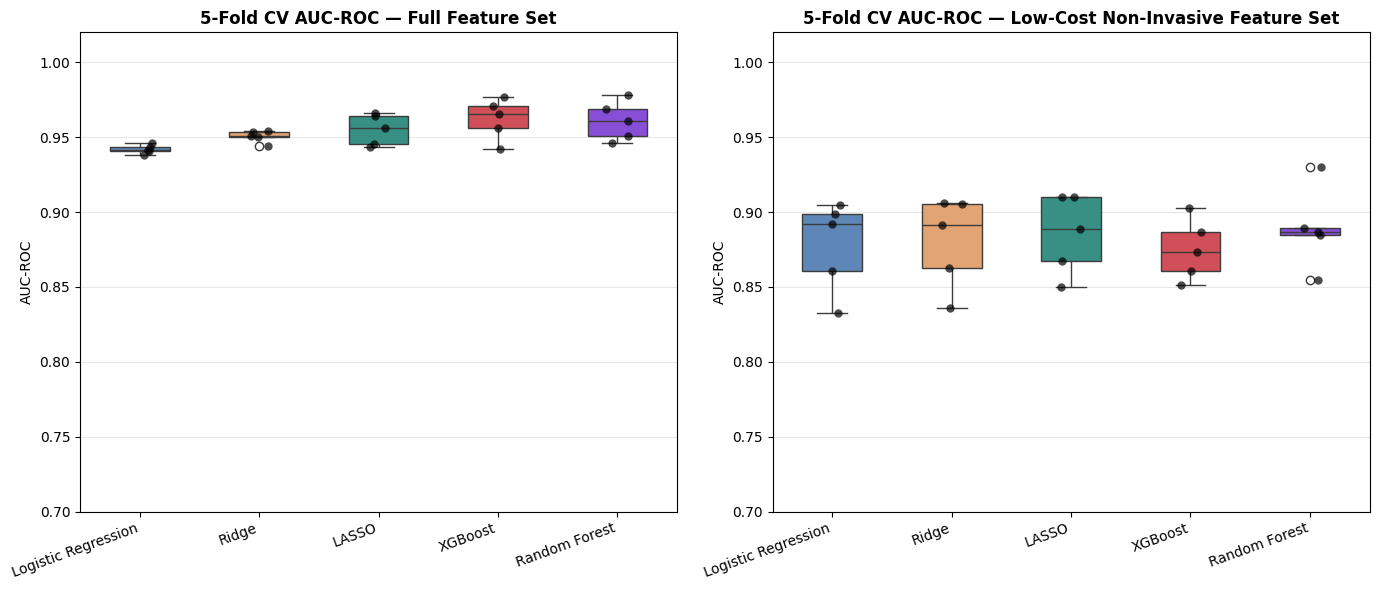

Saved to data/processed/model_comparison_auc.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
PALETTE = ['#4F86C6', '#F4A261', '#2a9d8f', '#E63946', '#8338ec']

for ax, fold_df, title in zip(
    axes,
    [fold_auc_full, fold_auc_low],
    ['Full Feature Set', 'Low-Cost Non-Invasive Feature Set']
):
    data_long = fold_df.melt(var_name='Model', value_name='AUC-ROC')
    sns.boxplot(
        data=data_long, x='Model', y='AUC-ROC',
        palette=PALETTE, width=0.5, ax=ax
    )
    sns.stripplot(
        data=data_long, x='Model', y='AUC-ROC',
        color='black', size=6, alpha=0.7, ax=ax
    )
    ax.set_title(f'5-Fold CV AUC-ROC — {title}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.set_ylim(0.7, 1.02)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/processed/model_comparison_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/model_comparison_auc.png')

## 7. Significance Heatmap

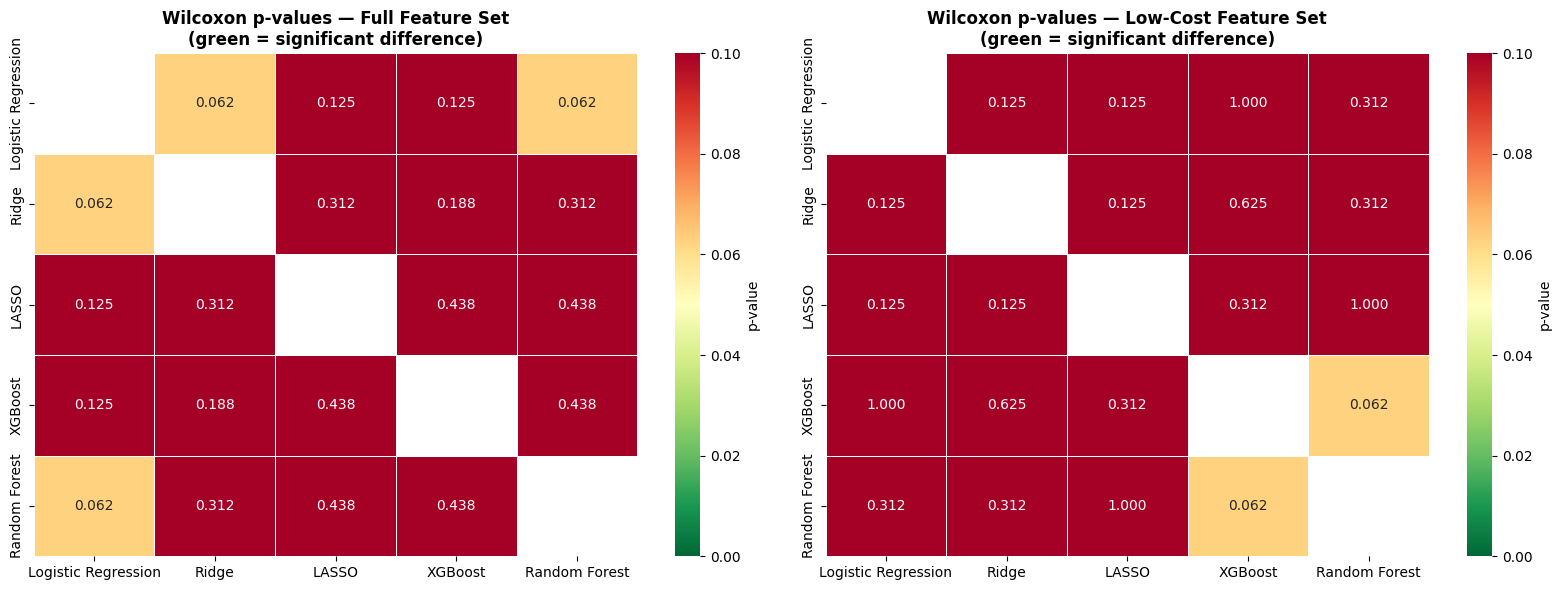

Saved to data/processed/model_comparison_significance.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, p_mat, title in zip(
    axes,
    [p_mat_full.astype(float), p_mat_low.astype(float)],
    ['Full Feature Set', 'Low-Cost Feature Set']
):
    mask = np.eye(len(p_mat), dtype=bool)  # hide diagonal
    sns.heatmap(
        p_mat, annot=True, fmt='.3f', cmap='RdYlGn_r',
        vmin=0, vmax=0.1, ax=ax, mask=mask,
        linewidths=0.5, cbar_kws={'label': 'p-value'}
    )
    ax.set_title(f'Wilcoxon p-values — {title}\n(green = significant difference)', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/processed/model_comparison_significance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to data/processed/model_comparison_significance.png')

## 8. Export Fold Scores

Saved for reference and potential inclusion in the report appendix.

In [9]:
fold_auc_full.to_csv('../data/processed/fold_auc_full_all_models.csv', index=False)
fold_auc_low.to_csv('../data/processed/fold_auc_low_all_models.csv', index=False)
print('Saved fold-level AUC scores for all models (full and low-cost).')

Saved fold-level AUC scores for all models (full and low-cost).
